# Titanic Exploratory Data Analysis

## Introduction
This notebook presents an exploratory data analysis (EDA) of the Titanic dataset. The aim is to explore the structure of the data, clean missing values, create visualisations, and answer key questions about passenger survival.

## Objectives
This analysis will answer the following questions:
1. What is the most important factor in determining whether a person was likely to survive the sinking of the Titanic?
2. In the movie, the upper-class passengers were given preference on lifeboats. Does this show in the data?
3. “Women and children first”. Was this the case?
4. What other interesting observation can be made from the dataset?

The notebook also explains each step of the analysis and the reasoning behind the data cleaning and visualisation choices.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Importing and Loading the Dataset

The first step in any EDA is to import the required libraries and load the dataset.  
`pandas` is used for handling the data, while `matplotlib` and `seaborn` are used for visualisation.

The Titanic dataset is then loaded so that we can inspect its structure, variables, and missing values before performing any analysis.

In [12]:
df = pd.read_csv("Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understanding the Structure of the Dataset

Before cleaning or analysing the data, it is important to understand the size of the dataset, the column names, the data types, and whether any values are missing.

This helps identify which variables are numerical and categorical, and shows where preprocessing may be needed before visualisation.

In [13]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

Shape of dataset: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values per column:
PassengerId      0
Survived         0
Pclass     

## Data Cleaning

The dataset contains missing values, so these must be handled before analysis.

- The `Age` column is filled with the median because age is a numerical variable and the median is less affected by extreme values than the mean.
- The `Embarked` column is filled with the mode because it is a categorical variable and the most common category is a sensible replacement.
- The `Cabin` column is dropped because it contains too many missing values, which would make it unreliable for meaningful analysis in this notebook.

These steps improve the usability of the dataset while preserving as much useful information as possible.

In [14]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

if "Cabin" in df.columns:
    df = df.drop("Cabin", axis=1)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Summary Statistics

After cleaning the data, the next step is to examine summary statistics. This helps identify the range and distribution of numerical variables such as age, fare, and the number of family members aboard.

These statistics provide useful context before moving on to visual exploration of survival patterns.

In [15]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.361582,0.523008,0.381594,NaN,32.204208,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.019697,1.102743,0.806057,NaN,49.693429,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN


## Survival Count

To begin the analysis, it is useful to look at the overall number of passengers who survived compared with those who did not.

This gives a broad overview of the outcome variable (`Survived`) before investigating which factors may have influenced survival.

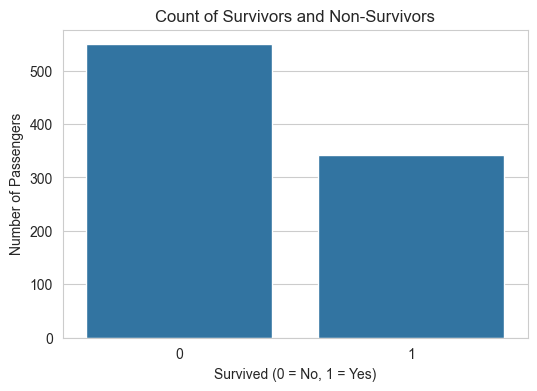

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Count of Survivors and Non-Survivors")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

## Survival by Gender

Gender is one of the most important variables to investigate because historical accounts often suggest that women were given a better chance of survival.

This visualisation compares survival outcomes between male and female passengers in order to determine whether gender was a major factor in survival.

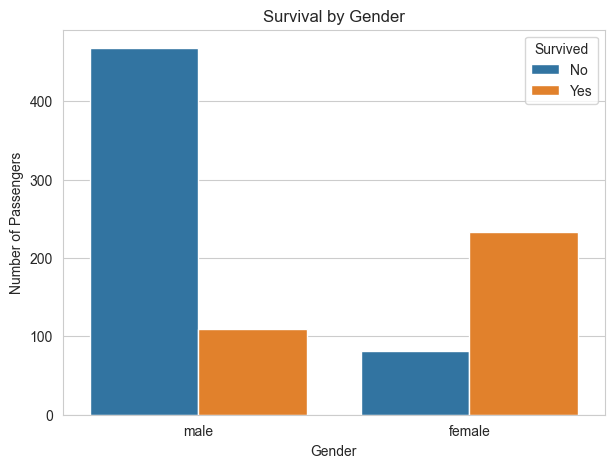

Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

gender_survival = df.groupby("Sex")["Survived"].mean()
print("Survival rate by gender:")
print(gender_survival)

## Interpretation: Most Important Survival Factor

The graph and survival rates by gender suggest that gender was one of the strongest factors affecting survival.

Female passengers had a much higher survival rate than male passengers. This indicates that being female greatly increased the likelihood of surviving the Titanic disaster. Based on this evidence, gender appears to be one of the most important factors in determining survival.

## Survival by Passenger Class

The next question is whether upper-class passengers were given preference on lifeboats, as often shown in the Titanic movie.

Passenger class (`Pclass`) can be used as an indicator of socio-economic status aboard the ship. By comparing survival across classes, we can determine whether first-class passengers had better survival outcomes than those in second or third class.

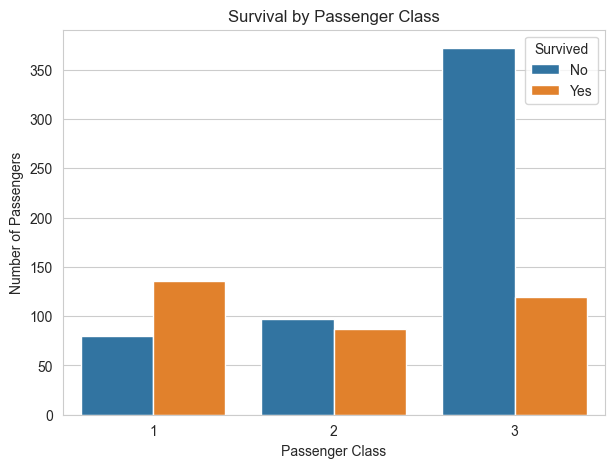

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

class_survival = df.groupby("Pclass")["Survived"].mean()
print("Survival rate by passenger class:")
print(class_survival)

## Interpretation: Were Upper-Class Passengers Given Preference?

The results show that passengers in first class had a noticeably higher survival rate than those in second and especially third class.

This supports the idea that upper-class passengers were given better access to lifeboats or had survival advantages during the disaster. Therefore, the data does show evidence that upper-class passengers were more likely to survive.

## Women and Children First

Another common claim is that “women and children first” was followed during the evacuation.

To explore this, age will be used to identify children, and survival will be compared across both age group and gender. In this notebook, children are defined as passengers younger than 16 years old.

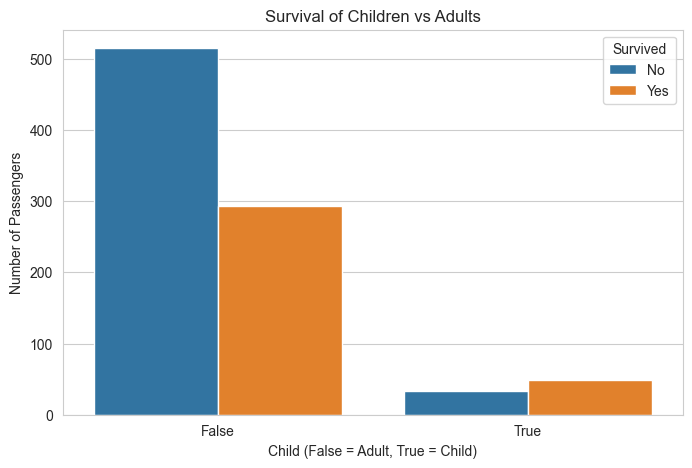

Survival rate for children vs adults:
Child
False    0.362624
True     0.590361
Name: Survived, dtype: float64


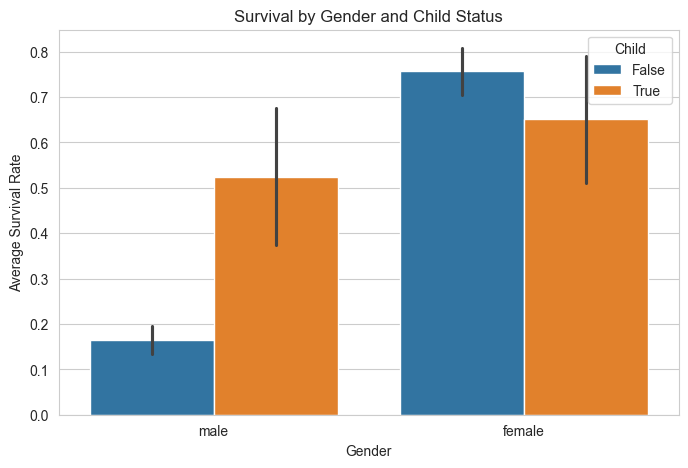

In [19]:
df["Child"] = df["Age"] < 16

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Child", hue="Survived")
plt.title("Survival of Children vs Adults")
plt.xlabel("Child (False = Adult, True = Child)")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

child_survival = df.groupby("Child")["Survived"].mean()
print("Survival rate for children vs adults:")
print(child_survival)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Sex", y="Survived", hue="Child")
plt.title("Survival by Gender and Child Status")
plt.xlabel("Gender")
plt.ylabel("Average Survival Rate")
plt.show()

## Interpretation: Was “Women and Children First” the Case?

The analysis suggests that women had much higher survival rates than men, and children also tended to survive at higher rates than many adults.

This provides support for the idea that “women and children first” was followed to some extent. However, the data may show that gender had a stronger effect than age alone, since adult women also survived at much higher rates than adult men.

## Additional Observation: Fare and Survival

For the additional observation, the relationship between fare and survival is explored.

Fare may reflect both passenger wealth and class position. Analysing fare can reveal whether passengers who paid more for tickets were more likely to survive, which may provide another perspective on inequality in survival outcomes.

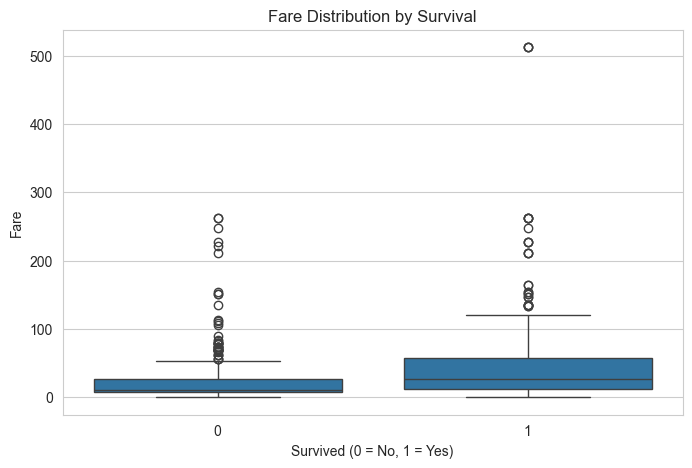

Average fare by survival:
Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

fare_survival = df.groupby("Survived")["Fare"].mean()
print("Average fare by survival:")
print(fare_survival)

## Interpretation: Additional Observation

The fare analysis shows that passengers who survived generally paid higher fares than those who did not survive.

This suggests that wealthier passengers, or those in better classes and locations on the ship, may have had a survival advantage. This observation supports the earlier finding that social class likely played an important role in survival.

## Conclusion

This exploratory data analysis examined the Titanic dataset in order to identify patterns related to survival.

### Main findings
- Gender appears to be one of the most important factors influencing survival, with women surviving at much higher rates than men.
- Passenger class also had a strong effect, with first-class passengers surviving more often than lower-class passengers.
- The idea of “women and children first” is partly supported by the data, especially for women.
- An additional observation showed that passengers who paid higher fares were more likely to survive.

Overall, the data suggests that both gender and social class played major roles in determining who survived the Titanic disaster.